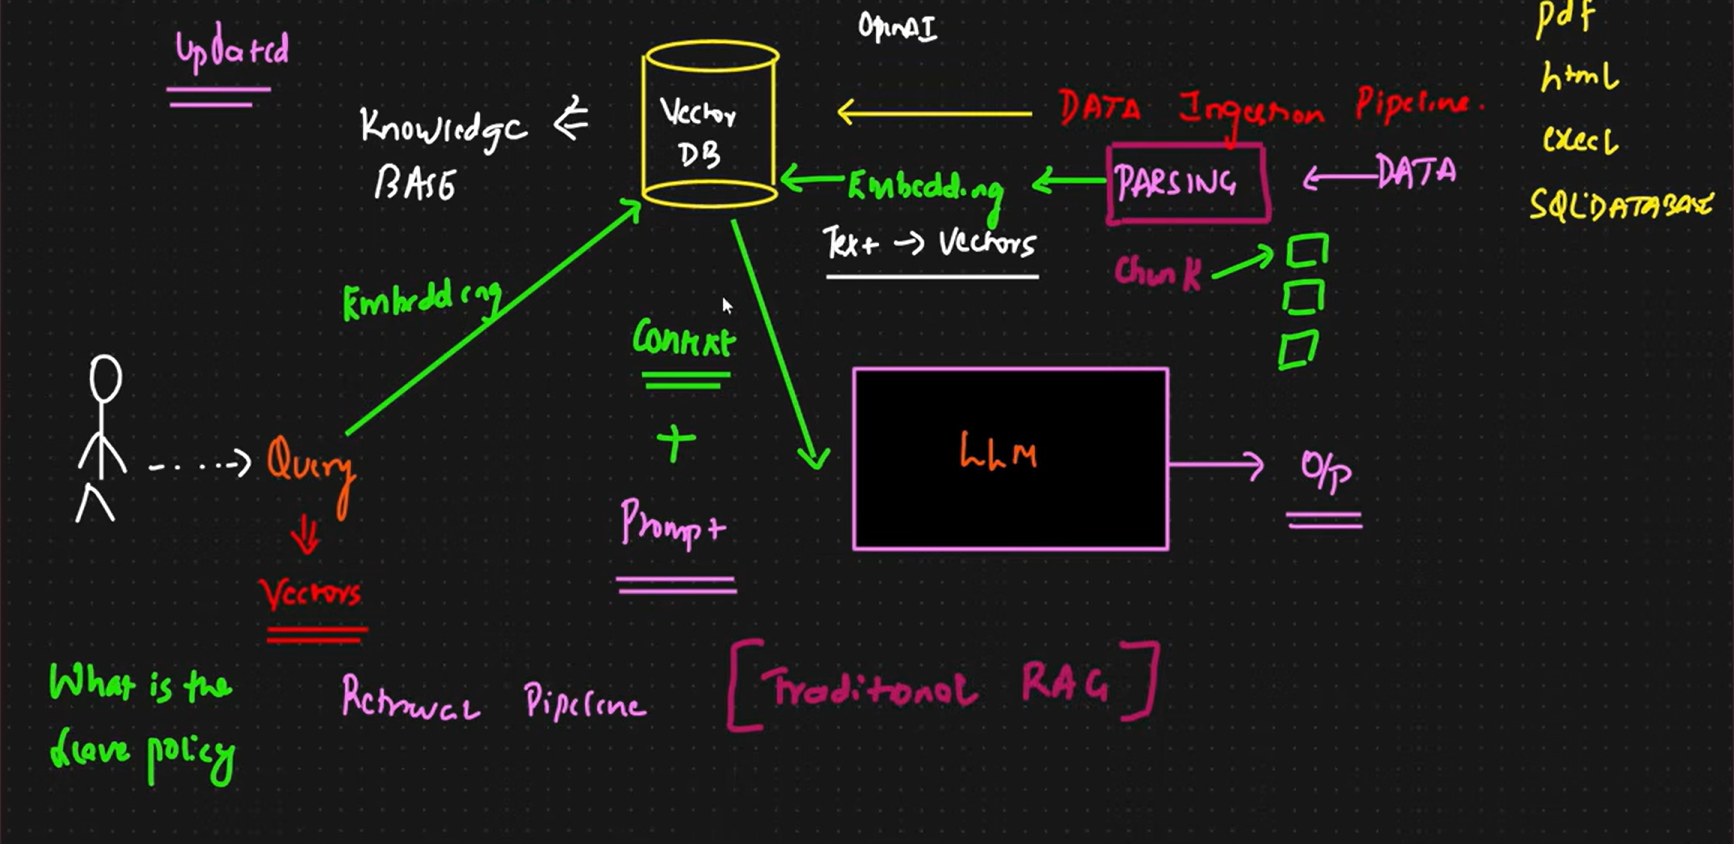

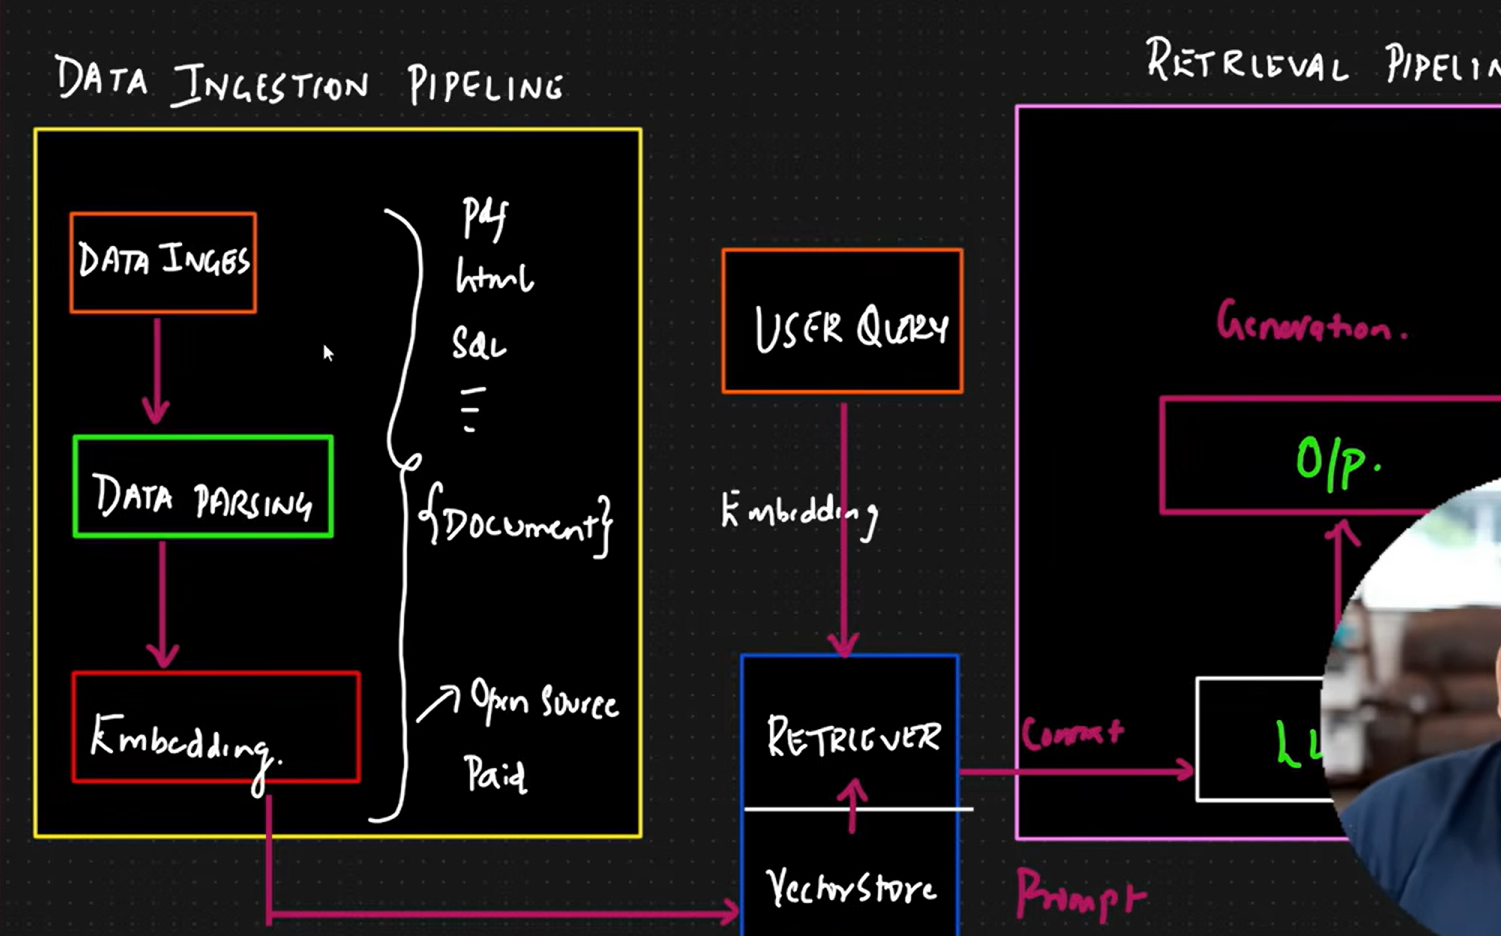

### There are 2 pipelines 
- **Data Ingestion Pipeline**
- **Data Retrieval Pipeline**

## 1) Data Ingestion Pipeline

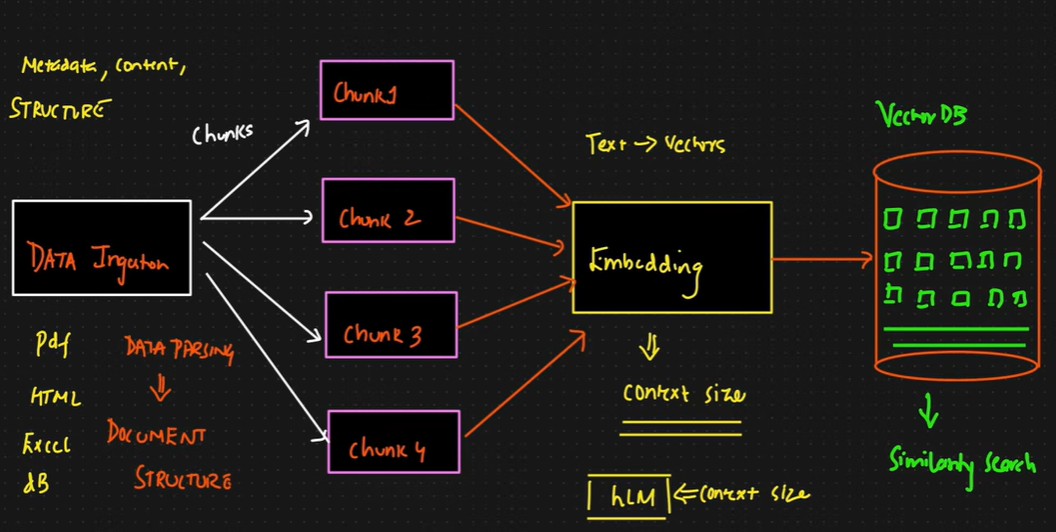

In [1]:
# Data Structure
from langchain_core.documents import Document

In [2]:
doc=Document(
    page_content="This is a sample document with some content I am using to create RAG  .",
    metadata={"source": "sample.txt","pages":1, "author": "Ammar", "date": "2023-09-15"}
)
doc

Document(metadata={'source': 'sample.txt', 'pages': 1, 'author': 'Ammar', 'date': '2023-09-15'}, page_content='This is a sample document with some content I am using to create RAG  .')

In [3]:
# Creating a simple txt file
import os
os.makedirs("../data/text_files", exist_ok=True)

In [4]:
sample_texts={
    "../data/text_files/python_intro.txt":"""Python Programming Introduction

Python is a high-level, interpreted programming language known for its simplicity and readability.
Created by Guido van Rossum and first released in 1991, Python has become one of the most popular
programming languages in the world.

Key Features:
- Easy to learn and use
- Extensive standard library
- Cross-platform compatibility
- Strong community support

Python is widely used in web development, data science, artificial intelligence, and automation.""",
    
    "../data/text_files/machine_learning.txt": """Machine Learning Basics

Machine learning is a subset of artificial intelligence that enables systems to learn and improve
from experience without being explicitly programmed. It focuses on developing computer programs
that can access data and use it to learn for themselves.

Types of Machine Learning:
1. Supervised Learning: Learning with labeled data
2. Unsupervised Learning: Finding patterns in unlabeled data
3. Reinforcement Learning: Learning through rewards and penalties

Applications include image recognition, speech processing, and recommendation systems
    
    
    """

}
for filepath,content in sample_texts.items():
    with open(filepath,'w',encoding="utf-8") as f:
        f.write(content)

print("✅ Sample text files created!")

✅ Sample text files created!


In [6]:
# Text Loader
from langchain_community.document_loaders import TextLoader

loader=TextLoader("../data/text_files/python_intro.txt", encoding="utf-8")
documents=loader.load()
print(documents)

[Document(metadata={'source': '../data/text_files/python_intro.txt'}, page_content='Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popular\nprogramming languages in the world.\n\nKey Features:\n- Easy to learn and use\n- Extensive standard library\n- Cross-platform compatibility\n- Strong community support\n\nPython is widely used in web development, data science, artificial intelligence, and automation.')]


In [7]:
### Directory Loader
from langchain_community.document_loaders import DirectoryLoader

## load all the text files from the directory
dir_loader=DirectoryLoader(
    "../data/text_files",
    glob="**/*.txt", ## Pattern to match files  
    loader_cls= TextLoader, ##loader class to use
    loader_kwargs={'encoding': 'utf-8'},
    show_progress=False

)

documents=dir_loader.load()
documents

[Document(metadata={'source': '..\\data\\text_files\\machine_learning.txt'}, page_content='Machine Learning Basics\n\nMachine learning is a subset of artificial intelligence that enables systems to learn and improve\nfrom experience without being explicitly programmed. It focuses on developing computer programs\nthat can access data and use it to learn for themselves.\n\nTypes of Machine Learning:\n1. Supervised Learning: Learning with labeled data\n2. Unsupervised Learning: Finding patterns in unlabeled data\n3. Reinforcement Learning: Learning through rewards and penalties\n\nApplications include image recognition, speech processing, and recommendation systems\n\n\n    '),
 Document(metadata={'source': '..\\data\\text_files\\python_intro.txt'}, page_content='Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popu

In [4]:
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
from langchain_community.document_loaders import DirectoryLoader

## load all the text files from the directory
dir_loader=DirectoryLoader(
    "../data/pdf",
    glob="**/*.pdf", ## Pattern to match files  
    loader_cls= PyMuPDFLoader, ##loader class to use
    show_progress=False

)

pdf_documents=dir_loader.load()
pdf_documents

[Document(metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'source': '..\\data\\pdf\\attention.pdf', 'file_path': '..\\data\\pdf\\attention.pdf', 'total_pages': 15, 'format': 'PDF 1.5', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'trapped': '', 'modDate': 'D:20240410211143Z', 'creationDate': 'D:20240410211143Z', 'page': 0}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗†\nUniversity of Toronto\naidan@cs.toronto.edu\nŁukasz Kaiser∗\nGoogle

In [8]:
type(pdf_documents[0])

langchain_core.documents.base.Document

In [9]:
# For Excel files
from langchain_community.document_loaders import UnstructuredExcelLoader

dir_loader=DirectoryLoader(
    "../data/excel",
    glob="**/*.xlsx", ## Pattern to match files  
    loader_cls= UnstructuredExcelLoader, ##loader class to use
    show_progress=False
)

documents = dir_loader.load()

print(documents)

Error loading file ..\data\excel\customers_sample.xlsx


ModuleNotFoundError: No module named 'unstructured'